# **ANALISIS DE SENTIMIENTOS SOBRE LA SITUACION ECONOMICA ARGENTINA**

## **DESCARGA DE LIBRERIAS**

In [71]:
!pip install sentiment-analysis-spanish

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sentiment_analysis_spanish import sentiment_analysis
from tensorflow import keras
from wordcloud import WordCloud


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print('Librerias importadas')

Librerias importadas


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **LINEAMIENTOS DEL PROYECTO**

### **DESCRIPCION DEL CONTEXTO**

En el contexto actual de la economia argentina, caracterizado por una alta volatilidad, inflacion y cambios regulatorios constantes, los indicadores macroeconomicos tradicionales (IPC, valor del dólar, riesgo país) a menudo no llegan a capturar el "sentimiento real" de la poblacion. Las organizaciones y analistas carecen de herramientas cualitativas agiles que permitan entender como impactan estos fenomenos en la salud mental, las decisiones de consumo y las expectativas a futuro de las personas de a pie. El problema radica en transformar opiniones subjetivas y textos libres en insights accionables y cuantificables.

### **OBJETIVO**

Analizar la percepcion de la situacion economica actual en Argentina aplicando tecnicas de Procesamiento de Lenguaje Natural (NLP) sobre datos de encuestas primarias. El objetivo es identificar los principales topicos de preocupacion (topicos latentes), medir la polaridad del sentimiento (positivo/negativo/neutro) y correlacionar estas emociones con variables demograficas y niveles de estres declarados.

### **DETALLE E IMPORTACION DEL DATASET**

El dataset proviene de una encuesta realizada por mi, llamada "Percepcion de la Situacion Economica Actual". La misma fue distribuida a traves de redes sociales y grupos de Whatsapp y se consiguieron 93 respuestas.

In [72]:
!gdown 1kL1mdMCZT8Dn294beKo2OAT3-WYVyVnu
df = pd.read_excel('Percepción de la Situación Económica Actual.xlsx')

Downloading...
From: https://drive.google.com/uc?id=1kL1mdMCZT8Dn294beKo2OAT3-WYVyVnu
To: /content/Percepción de la Situación Económica Actual.xlsx
100% 26.2k/26.2k [00:00<00:00, 41.6MB/s]


El dataset contiene variables de tres tipos:
datos del encuestado, numericas y texto libre.

1. **Datos del encuestado:**
    *  Rango de edad: Categoria etaria del encuestado.
    *  Nivel de estudios: Maximo nivel educativo alcanzado.
    *  Situacion laboral: Estado ocupacional principal (ej. Relacion de dependencia, Freelance).

2. **Numericas:**
    *  Calificacion Situación Pais: Percepcion general de la economia (1=Pesima / Critica, 5=Excelente / Prospera).
    *  Optimismo Futuro: Expectativa sobre la economia personal para el próximo año (1=Muy Pesimista, 5=Muy Optimista).
    *  Nivel de Estres: Grado de ansiedad generado por noticias economicas (1=Ninguna ansiedad, 5=Ansiedad extrema).

3. **Texto libre:**
    *  Mayor preocupacion: Texto libre describiendo el principal dolor economico.
    *  Aspecto positivo: Texto para expresas virtudes en la situacion actual
    *  Consumo afectado: Rubro donde mas noto la inflacion.
    *  Amigo extranjero: Situacion hipotetica en donde se le plantea que opinion sincera le diria a esta persona
    *  Emoción predominante: Palabra o frase que define su estado de animo (ej. "Angustia", "Esperanza").


In [73]:
print("Filas y columnas:", df.shape)

Filas y columnas: (93, 13)


In [74]:
df.head()

,Marca temporal,Tenes mas de 16 años?,¿Cuál es tu rango de edad?,¿Cuál es tu nivel de estudios alcanzado (completo o en curso)?,¿Cuál es tu situación laboral principal?,"En una escala del 1 al 5, ¿cómo calificas la situación económica actual del país?","Pensando en tu economía personal para el próximo año, ¿cuál es tu nivel de optimismo?",¿Qué nivel de estrés o ansiedad te genera leer o escuchar noticias sobre la economía hoy en día?,¿Cuál es tu mayor preocupación económica hoy en día y por qué?,"A pesar del contexto, ¿encuentras alguna oportunidad o aspecto positivo en tu situación? (Si no ves ninguna, explica por qué).",¿En qué consumo cotidiano has sentido más el impacto de los precios recientemente?,"Si un amigo del extranjero te preguntara si es un buen momento para venir a vivir e invertir en el país, ¿qué le responderías y por qué?","Si tuvieras que definir tu estado de ánimo actual respecto al dinero con una sola emoción (ej: Angustia, Tranquilidad, Bronca, Fe), ¿cuál elegirías y por qué?"
0,2025-12-24 16:47:27.786,Si,36-50,Terciario / Universitario,Independiente / Freelance / Dueño,2,5,4,Inestabilidad económica por inflación,Si,Carne,"No, porque es una economía inestable",Agradecida por lo logrado
1,2025-12-24 16:50:55.726,Si,36-50,Terciario / Universitario,Empleado en relación de dependencia,2,3,2,Llegar a fin de mes con tranquilidad,Si,En los alimentos y servicios,Que no porque hay mas inseridumbre en este mom...,Bronca porque no hay no hay ninguna certeza en...
2,2025-12-24 16:56:57.115,Si,26-35,Terciario / Universitario,Estudiante,1,4,2,Mi mayor preocupación es no poder pagar el alq...,"Si la encuentro,porque la carrera que elegí es...",En la carne,"Le diría que no,porque no es un país estable y...","Bronca,porque el dinero es algo fundamental pa..."
3,2025-12-24 17:08:45.403,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,3,4,2,Los sueldos bajos,Si,Ninguno,"Que si, es muy arriesgado pero si sale buen, v...","Fe, hay esperanza en que todo mejorará. Espere..."
4,2025-12-25 19:48:03.157,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,1,2,1,No llegar a fin de mes y ver cómo cada día hay...,"Al trabajar en blanco, tengo un sueldo que por...",Las comidas y la indumentaria,"Que todavia no, porque ni en dólares se recomi...",Angustia


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 13 columns):
 #   Column                                                                                                                                                            Non-Null Count  Dtype         
---  ------                                                                                                                                                            --------------  -----         
 0   Marca temporal                                                                                                                                                    93 non-null     datetime64[ns]
 1   Tenes mas de 16 años?                                                                                                                                             93 non-null     object        
 2    ¿Cuál es tu rango de edad?                                                                         

## **EDICION DE BASE DE DATOS**

### **CAMBIO DE NOMBRES DE COLUMNAS**

Para analizar los datos, primero se realizara un cambio de nombres ya que las columnas tienen descripciones muy largas.

1. Marca temporal --> fecha
2. Tenes mas de 16 años? --> filtro_edad
3. ¿Cuál es tu rango de edad? --> rango_edad
4. ¿Cuál es tu nivel de estudios alcanzado (completo o en curso)? --> estudios
5. ¿Cuál es tu situación laboral principal? --> trabajo
6. En una escala del 1 al 5, ¿cómo calificas la situación económica actual del país? --> score_situacion_pais
7. Pensando en tu economía personal para el próximo año, ¿cuál es tu nivel de optimismo? --> score_optimismo
8. ¿Qué nivel de estrés o ansiedad te genera leer o escuchar noticias sobre la economía hoy en día? --> score_estres
9. ¿Cuál es tu mayor preocupación económica hoy en día y por qué? --> txt_preocupacion
10. A pesar del contexto, ¿encuentras alguna oportunidad o aspecto positivo en tu situación? (Si no ves ninguna, explica por qué) --> txt_oportunidad
11. ¿En qué consumo cotidiano has sentido más el impacto de los precios recientemente? --> txt_consumo
12. Si un amigo del extranjero te preguntara si es un buen momento para venir a vivir e invertir en el país, ¿qué le responderías y por qué? --> txt_extranjero
13. Si tuvieras que definir tu estado de ánimo actual respecto al dinero con una sola emoción (ej: Angustia, Tranquilidad, Bronca, Fe), ¿cuál elegirías y por qué? --> txt_emocion

Por ultimo, se hacen 3 prints para ver como queda la base con estas nuevas columnas.

In [76]:
# Creacion de df_actualizado
df_actualizado = df.copy()

In [77]:
# Se cambian los nombres de las columnas como se detallo anteriormente
nuevos_nombres = ['fecha','filtro_edad','edad','estudios','trabajo','score_situacion_pais','score_optimismo','score_estres','txt_preocupacion','txt_oportunidad','txt_consumo','txt_extranjero','txt_emocion']
df_actualizado.columns = nuevos_nombres

In [78]:
# Print 1
print("Filas y columnas:", df_actualizado.shape)

Filas y columnas: (93, 13)


In [79]:
# Print 2
df_actualizado.head()

,fecha,filtro_edad,edad,estudios,trabajo,score_situacion_pais,score_optimismo,score_estres,txt_preocupacion,txt_oportunidad,txt_consumo,txt_extranjero,txt_emocion
0,2025-12-24 16:47:27.786,Si,36-50,Terciario / Universitario,Independiente / Freelance / Dueño,2,5,4,Inestabilidad económica por inflación,Si,Carne,"No, porque es una economía inestable",Agradecida por lo logrado
1,2025-12-24 16:50:55.726,Si,36-50,Terciario / Universitario,Empleado en relación de dependencia,2,3,2,Llegar a fin de mes con tranquilidad,Si,En los alimentos y servicios,Que no porque hay mas inseridumbre en este mom...,Bronca porque no hay no hay ninguna certeza en...
2,2025-12-24 16:56:57.115,Si,26-35,Terciario / Universitario,Estudiante,1,4,2,Mi mayor preocupación es no poder pagar el alq...,"Si la encuentro,porque la carrera que elegí es...",En la carne,"Le diría que no,porque no es un país estable y...","Bronca,porque el dinero es algo fundamental pa..."
3,2025-12-24 17:08:45.403,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,3,4,2,Los sueldos bajos,Si,Ninguno,"Que si, es muy arriesgado pero si sale buen, v...","Fe, hay esperanza en que todo mejorará. Espere..."
4,2025-12-25 19:48:03.157,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,1,2,1,No llegar a fin de mes y ver cómo cada día hay...,"Al trabajar en blanco, tengo un sueldo que por...",Las comidas y la indumentaria,"Que todavia no, porque ni en dólares se recomi...",Angustia


In [80]:
# Print 3
df_actualizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 93 non-null     datetime64[ns]
 1   filtro_edad           93 non-null     object        
 2   edad                  93 non-null     object        
 3   estudios              93 non-null     object        
 4   trabajo               93 non-null     object        
 5   score_situacion_pais  93 non-null     int64         
 6   score_optimismo       93 non-null     int64         
 7   score_estres          93 non-null     int64         
 8   txt_preocupacion      92 non-null     object        
 9   txt_oportunidad       93 non-null     object        
 10  txt_consumo           93 non-null     object        
 11  txt_extranjero        93 non-null     object        
 12  txt_emocion           93 non-null     object        
dtypes: datetime64[ns](1), 

### **CONCATENADO DE TEXTO**

En esta etapa, se aplico una tecnica de Ingenieria de Caracteristicas sobre datos no estructurados.

La encuesta captura opiniones fragmentadas en 5 preguntas abiertas. Analizarlas por separado diluye el contexto emocional del encuestado.

Al concatenar todas las respuestas textuales en una unica variable (txt_completo), se logra:

1. Generar un documento mas robusto por usuario, aumentando la cantidad de tokens disponibles para el modelo.

2. El algoritmo de NLP analiza la coherencia global del sentimiento del usuario, cruzando sus preocupaciones con sus esperanzas.

Nuevamente se hacen 3 prints para ver como queda conformada la base de datos.

In [81]:
# Creacion de df_txt_resumido para sostener el df_actualizado ante cualquier necesidad
df_txt_resumido = df_actualizado.copy()

In [82]:
# Columnas de texto originales unidas para mayor facilidad en el codigo
cols_texto = ['txt_preocupacion', 'txt_oportunidad', 'txt_consumo', 'txt_extranjero', 'txt_emocion']

In [83]:
# Rellenar nulos con espacios vacios para evitar errores
df_txt_resumido[cols_texto] = df_txt_resumido[cols_texto].fillna('')

In [84]:
# Creacion de la nueva columna 'txt_completo' uniendo todo con espacios
df_txt_resumido['txt_completo'] = (df_txt_resumido['txt_preocupacion'] + " " + df_txt_resumido['txt_oportunidad'] + " " + df_txt_resumido['txt_consumo'] + " " + df_txt_resumido['txt_extranjero'] + " " + df_txt_resumido['txt_emocion'])

In [85]:
# Eliminacion de las 5 columnas originales
df_txt_resumido.drop(columns=cols_texto, inplace=True)

In [86]:
# Print 1
print("Filas y columnas:", df_txt_resumido.shape)

Filas y columnas: (93, 9)


In [87]:
# Print 2
df_txt_resumido.head()

,fecha,filtro_edad,edad,estudios,trabajo,score_situacion_pais,score_optimismo,score_estres,txt_completo
0,2025-12-24 16:47:27.786,Si,36-50,Terciario / Universitario,Independiente / Freelance / Dueño,2,5,4,Inestabilidad económica por inflación Si Carn...
1,2025-12-24 16:50:55.726,Si,36-50,Terciario / Universitario,Empleado en relación de dependencia,2,3,2,Llegar a fin de mes con tranquilidad Si En lo...
2,2025-12-24 16:56:57.115,Si,26-35,Terciario / Universitario,Estudiante,1,4,2,Mi mayor preocupación es no poder pagar el alq...
3,2025-12-24 17:08:45.403,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,3,4,2,"Los sueldos bajos Si Ninguno Que si, es muy ar..."
4,2025-12-25 19:48:03.157,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,1,2,1,No llegar a fin de mes y ver cómo cada día hay...


In [88]:
# Print 3
df_txt_resumido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 93 non-null     datetime64[ns]
 1   filtro_edad           93 non-null     object        
 2   edad                  93 non-null     object        
 3   estudios              93 non-null     object        
 4   trabajo               93 non-null     object        
 5   score_situacion_pais  93 non-null     int64         
 6   score_optimismo       93 non-null     int64         
 7   score_estres          93 non-null     int64         
 8   txt_completo          93 non-null     object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 6.7+ KB


### **INDICE DE BIENESTAR**

Para simplificar el analisis y evitar la dispersion de metricas, se cosntruye una nueva variable sintetica llamada Indice de Bienestar. Esta metrica unifica las tres dimensiones cuantitativas de la encuesta.

Logica de Construccion:
* Las variables de Pais y Optimismo tienen polaridad positiva (5 es mejor). Sin embargo, la variable Estres tiene polaridad negativa (5 es peor). Para que se sumen coherentemente, se aplica una inversion lineal al estres:
estres_invertido = 6 - score_estres.

* El indice final es la suma lineal de los tres componentes, resultando en una escala de 3  a 15. Esto facilita la segmentacion de usuarios en el Analisis Exploratorio.

Para seguir con la logica anterior, se visualizan los 3 prints finales para ver como queda conformada la base con la que se va a trabajar.

In [89]:
# Creacion de df_final para sostener el df_txt_resumido ante cualquier necesidad
df_final = df_txt_resumido.copy()

In [90]:
# Se invierte el estres
estres_invertido = 6 - df_final['score_estres']

In [91]:
# Calculo del indice de bienestar
df_final['indice_bienestar'] = df_final['score_situacion_pais'] + df_final['score_optimismo'] + estres_invertido

In [92]:
# Columnas de puntaje original unidas para mayor facilidad en el codigo
cols_scores = ['score_situacion_pais', 'score_optimismo', 'score_estres']

In [93]:
# Eliminacion de las 3 columnas originales
df_final.drop(columns=cols_scores, inplace=True)

In [94]:
# Print 1
print("Filas y columnas:", df_final.shape)

Filas y columnas: (93, 7)


In [95]:
# Print 2
df_final.head()

,fecha,filtro_edad,edad,estudios,trabajo,txt_completo,indice_bienestar
0,2025-12-24 16:47:27.786,Si,36-50,Terciario / Universitario,Independiente / Freelance / Dueño,Inestabilidad económica por inflación Si Carn...,9
1,2025-12-24 16:50:55.726,Si,36-50,Terciario / Universitario,Empleado en relación de dependencia,Llegar a fin de mes con tranquilidad Si En lo...,9
2,2025-12-24 16:56:57.115,Si,26-35,Terciario / Universitario,Estudiante,Mi mayor preocupación es no poder pagar el alq...,9
3,2025-12-24 17:08:45.403,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,"Los sueldos bajos Si Ninguno Que si, es muy ar...",11
4,2025-12-25 19:48:03.157,Si,16-25,Terciario / Universitario,Empleado en relación de dependencia,No llegar a fin de mes y ver cómo cada día hay...,8


In [96]:
# Print 3
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             93 non-null     datetime64[ns]
 1   filtro_edad       93 non-null     object        
 2   edad              93 non-null     object        
 3   estudios          93 non-null     object        
 4   trabajo           93 non-null     object        
 5   txt_completo      93 non-null     object        
 6   indice_bienestar  93 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 5.2+ KB


## **ANALISIS EXPLORATORIO DE DATOS**

Antes de aplicar modelos complejos, se realiza un analisis descriptivo para comprender la estructura y distribucion de nuestra nueva variable objetivo (Indice de Bienestar) y el perfil demografico de la muestra.

Tecnicas utilizadas:

* Calculo de medidas de tendencia central y dispersion para detectar sesgos en la muestra.

* Uso de histogramas para validar si los datos siguen una distribucion normal o presentan asimetrias hacia el pesimismo.

* Uso de Boxplots para cruzar la variable numerica  con variables categoricas, permitiendo detectar patrones de comportamiento por grupos poblacionales.

In [97]:
# Configuracion de las medidas estadisticas de las variables numericas
round(pd.concat([df_actualizado[cols_scores].describe(),df_final[['indice_bienestar']].describe()], axis=1),2)

,score_situacion_pais,score_optimismo,score_estres,indice_bienestar
count,93.00,93.00,93.00,93.00
mean,2.37,3.16,3.11,8.42
std,1.04,1.19,1.31,2.82
min,1.00,1.00,1.00,3.00
25%,2.00,2.00,2.00,6.00
50%,2.00,3.00,3.00,8.00
75%,3.00,4.00,4.00,11.00
max,5.00,5.00,5.00,15.00


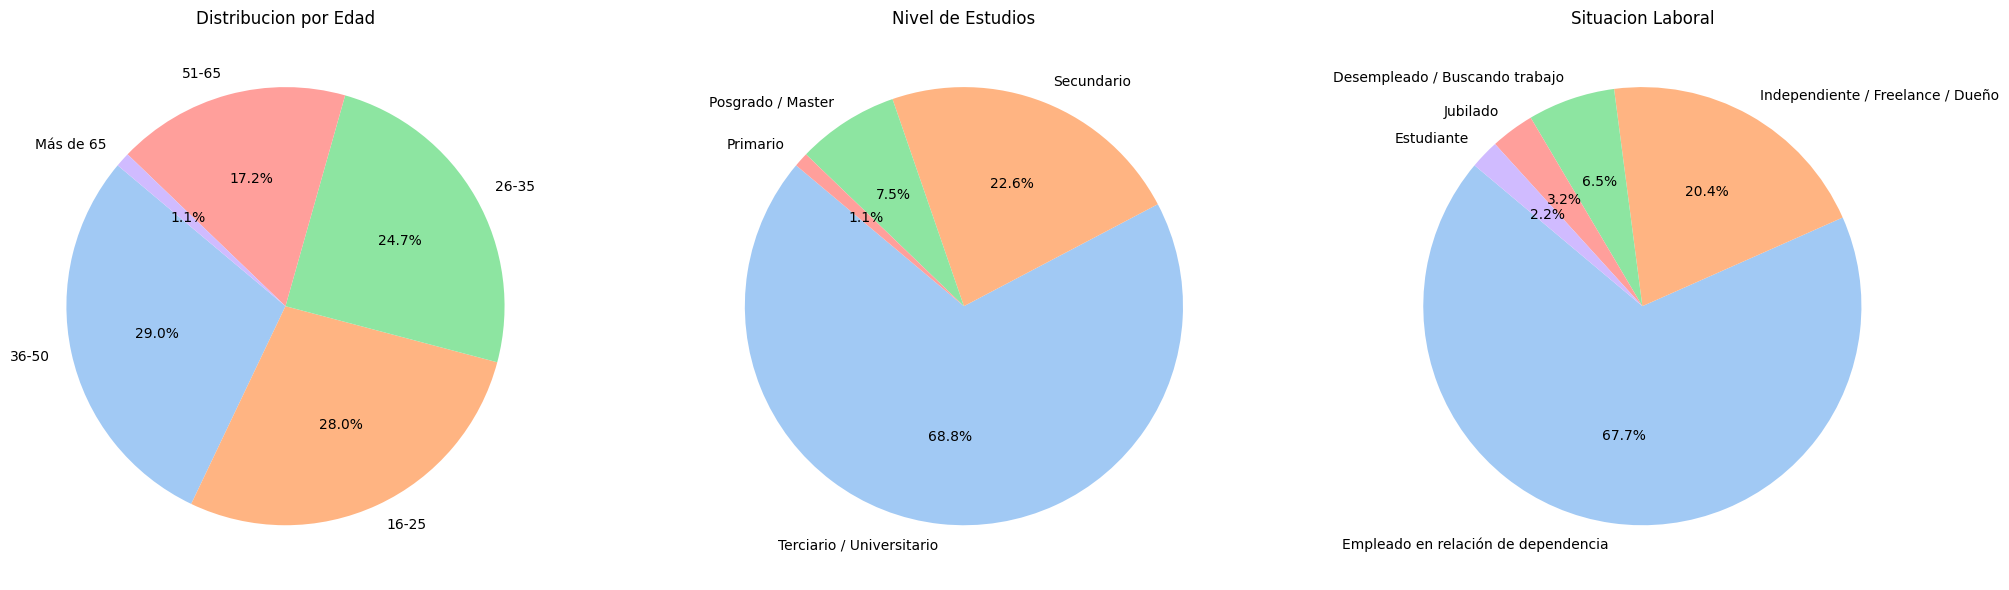

In [98]:
# Configuracion de los graficos de tortas
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

colores = sns.color_palette('pastel')

data_edad = df_final['edad'].value_counts()
axes[0].pie(data_edad, labels=data_edad.index, autopct='%1.1f%%', startangle=140, colors=colores)
axes[0].set_title('Distribucion por Edad')

data_estudios = df_final['estudios'].value_counts()
axes[1].pie(data_estudios, labels=data_estudios.index, autopct='%1.1f%%', startangle=140, colors=colores)
axes[1].set_title('Nivel de Estudios')

data_trabajo = df_final['trabajo'].value_counts()
axes[2].pie(data_trabajo, labels=data_trabajo.index, autopct='%1.1f%%', startangle=140, colors=colores)
axes[2].set_title('Situacion Laboral')

plt.tight_layout()
plt.show()

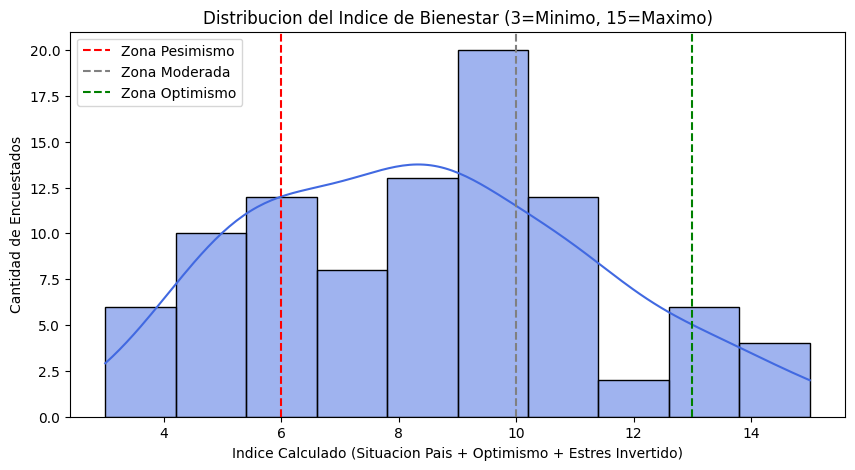

In [99]:
# Configuracion del Historigrama
plt.figure(figsize=(10, 5))

sns.histplot(df_final['indice_bienestar'], kde=True, bins=10, color='royalblue')

plt.axvline(x=6, color='red', linestyle='--', label='Zona Pesimismo')
plt.axvline(x=10, color='gray', linestyle='--', label='Zona Moderada')
plt.axvline(x=13, color='green', linestyle='--', label='Zona Optimismo')

plt.title('Distribucion del Indice de Bienestar (3=Minimo, 15=Maximo)')
plt.xlabel('Indice Calculado (Situacion Pais + Optimismo + Estres Invertido)')
plt.ylabel('Cantidad de Encuestados')
plt.legend()
plt.show()


/tmp/ipython-input-516772937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='indice_bienestar', y='edad', data=df_final, palette='viridis', ax=axes[0])
/tmp/ipython-input-516772937.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='indice_bienestar', y='trabajo', data=df_final, palette='magma', ax=axes[1])
/tmp/ipython-input-516772937.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='indice_bienestar', y='estudios', data=df_final, palette='plasma', ax=axes[2])


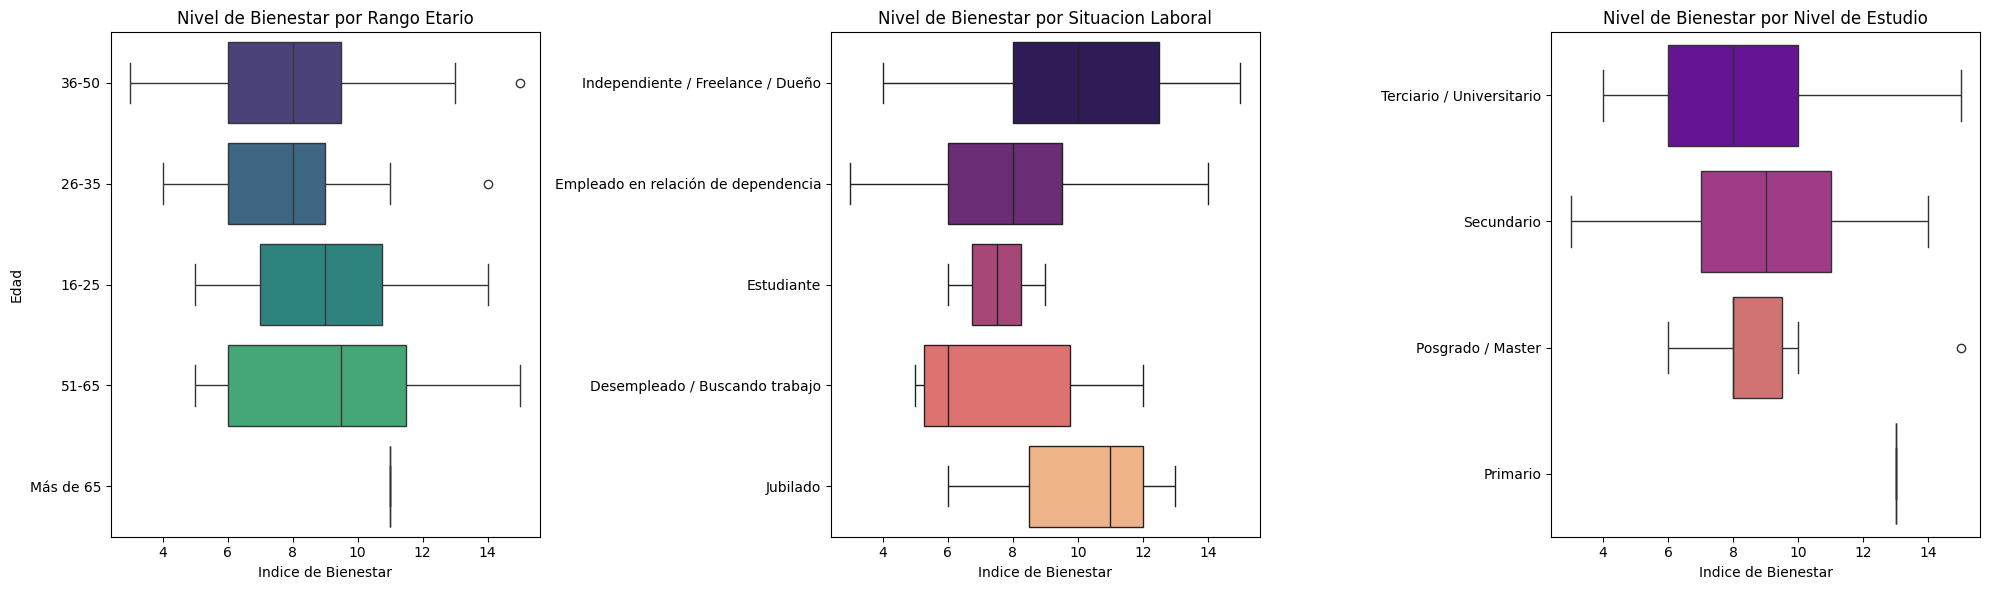

In [100]:
# Configuracion de los Boxplots

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(x='indice_bienestar', y='edad', data=df_final, palette='viridis', ax=axes[0])
axes[0].set_title('Nivel de Bienestar por Rango Etario')
axes[0].set_xlabel('Indice de Bienestar')
axes[0].set_ylabel('Edad')

sns.boxplot(x='indice_bienestar', y='trabajo', data=df_final, palette='magma', ax=axes[1])
axes[1].set_title('Nivel de Bienestar por Situacion Laboral')
axes[1].set_xlabel('Indice de Bienestar')
axes[1].set_ylabel('')

sns.boxplot(x='indice_bienestar', y='estudios', data=df_final, palette='plasma', ax=axes[2])
axes[2].set_title('Nivel de Bienestar por Nivel de Estudio')
axes[2].set_xlabel('Indice de Bienestar')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### **CONCLUSIONES PARCIALES**

A partir de la visualizacion de los datos demograficos y el indice de bienestar, observamos los primeros patrones clave:

* El histograma del indice muestra una clara tendencia hacia la zona baja/media de la escala. Esto sugiere que, estructuralmente, la muestra parte de una base de estres o insatisfaccion con la coyuntura, independientemente de su opinion textual.

* Los diagramas de caja (Boxplots) nos permiten identificar si existen grupos mas vulnerables. Por ejemplo, es relevante observar si la mediana del bienestar es inferior en los grupos mas jovenes (menor estabilidad laboral) o en aquellos con situacion laboral precaria (desempleados/informales), lo cual validaria que la crisis no afecta a todos por igual.

Estos hallazgos numericos nos dan el contexto necesario para profundizar ahora en el "por que" de este malestar, utilizando el analisis de texto.

## **METODOLOGIA NLP**

### **TRANSFORMACION DE TEXTO**

Se transforma el texto en datos procesables por la maquina. Se aplica un pipeline estandar de preprocesamiento:

1. Normalizacion: Conversion a minusculas y eliminacion de caracteres especiales para reducir el ruido.

2. Tokenizacion: Segmentacion del texto continuo en unidades discretas.

3. Filtrado de Stopwords: Eliminacion de palabras funcionales que tienen alta frecuencia pero bajo contenido semantico, dejando solo las palabras clave que cargan el significado.

In [101]:
# Creacion del dataframe especifico para NLP
df_nlp = df_final.copy()

In [102]:
# Configuracion de Stopwords (Palabras que eliminaremos)
stop_words = set(stopwords.words('spanish'))
lista_ruido = ['fin', 'hace', 'si', 'no', 'porque', 'q', 'pq', 'mas', 'ser', 'hacer', 'tener', 'pais', 'país', 'argentina', 'nacion', 'gobierno', 'año', 'ano', 'dia', 'hoy', 'actual', 'ahora', 'economia', 'economico', 'economica', 'situacion','va', 'van', 'vamos', 'creo', 'veo', 'siento', 'gente']
stop_words.update(lista_ruido)

In [103]:
# Definicion de la Funcion de Limpieza
def procesar_texto(texto):
    # Convertir todo a minusculas
    texto = str(texto).lower()

    # Eliminar signos de puntuacion y numeros
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\d+', '', texto)

    # Tokenizacion
    tokens = word_tokenize(texto, language='spanish')

    # Filtrado de Stopwords
    tokens_limpios = [word for word in tokens if word not in stop_words]

    # Devolucion del texto limpio unido de nuevo
    return " ".join(tokens_limpios)

In [104]:
# Aplicacion de la limpieza
df_nlp['txt_limpio'] = df_nlp['txt_completo'].apply(procesar_texto)

In [105]:
# Verificacion del resultado
df_nlp[['txt_completo', 'txt_limpio']].head()

,txt_completo,txt_limpio
0,Inestabilidad económica por inflación Si Carn...,inestabilidad económica inflación carne econom...
1,Llegar a fin de mes con tranquilidad Si En lo...,llegar mes tranquilidad alimentos servicios in...
2,Mi mayor preocupación es no poder pagar el alq...,mayor preocupación poder pagar alquiler encuen...
3,"Los sueldos bajos Si Ninguno Que si, es muy ar...",sueldos bajos ninguno arriesgado sale buen muc...
4,No llegar a fin de mes y ver cómo cada día hay...,llegar mes ver cómo cada día endeudadisima tra...


### **NUBE DE PALABRAS**

Para comprender rapidamente los topicos dominantes en la mente de los encuestados, se genera una Nube de Palabras.

Permite responder a golpe de vista: ¿De que habla la gente cuando piensa en economia?

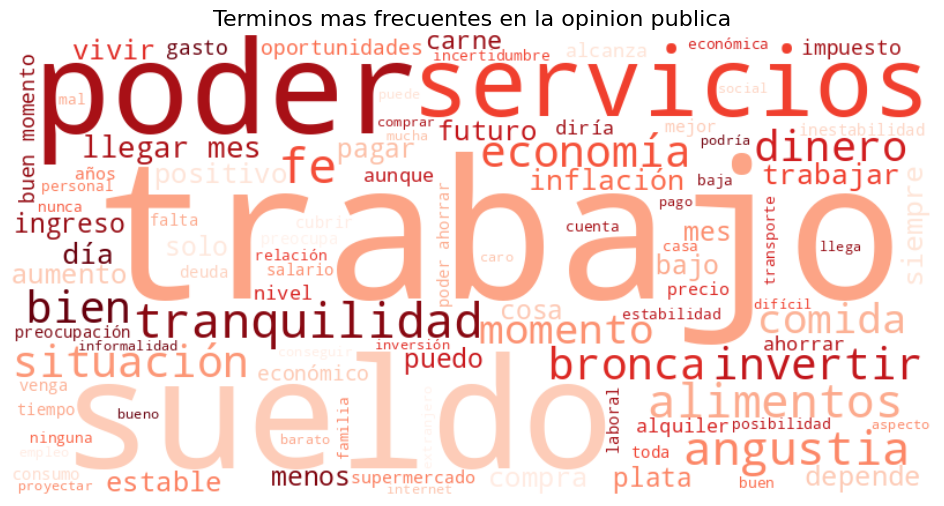

In [106]:
# Configuracion de la nube de palabras
texto_consolidado = " ".join(texto for texto in df_nlp['txt_limpio'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100, contour_width=1, contour_color='firebrick').generate(texto_consolidado)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Terminos mas frecuentes en la opinion publica', fontsize=16)
plt.show()

### **ANALISIS DE SENTIMIENTOS**

Se utiliza un modelo pre-entrenado para el idioma español que asigna una polaridad a cada texto. El modelo evalua la carga semantica de las palabras y devuelve un score continuo entre 0 (Sentimiento totalmente negativo) y 1 (Sentimiento totalmente positivo), lo que nos permite cuantificar la opinion publica de manera objetiva.

In [107]:
# Se inicializa el modelo de IA pre-entrenado
sentiment = sentiment_analysis.SentimentAnalysisSpanish()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [108]:
# Se calcula el puntaje de sentimiento
df_nlp['sentimiento_score'] = df_nlp['txt_completo'].apply(lambda x: sentiment.sentiment(x))

In [109]:
# Se clasifica el puntaje en etiquetas legibles
def clasificar_sentimiento(score):
    if score < 0.4:
        return 'Negativo'
    elif score > 0.6:
        return 'Positivo'
    else:
        return 'Neutral'

df_nlp['sentimiento_etiqueta'] = df_nlp['sentimiento_score'].apply(clasificar_sentimiento)

/tmp/ipython-input-2909311223.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentimiento_etiqueta', data=df_nlp, order=orden, palette=colores)


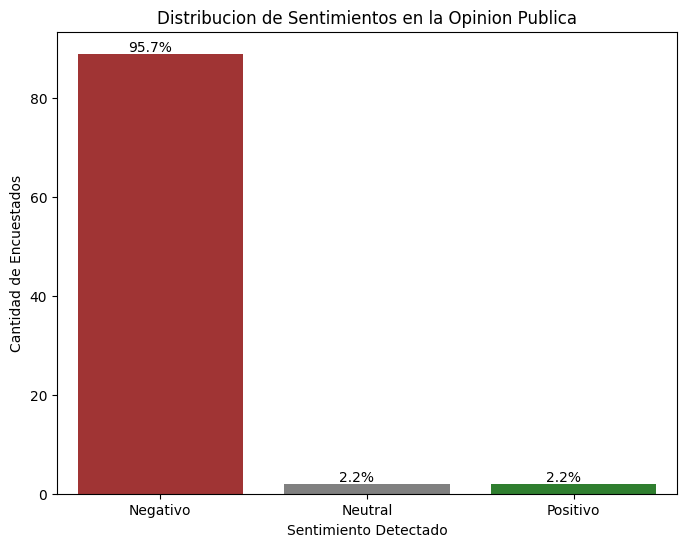

In [110]:
# Se visualiza los resultados
plt.figure(figsize=(8, 6))

orden = ['Negativo', 'Neutral', 'Positivo']
colores = {'Negativo': 'firebrick', 'Neutral': 'gray', 'Positivo': 'forestgreen'}

ax = sns.countplot(x='sentimiento_etiqueta', data=df_nlp, order=orden, palette=colores)

plt.title('Distribucion de Sentimientos en la Opinion Publica')
plt.xlabel('Sentimiento Detectado')
plt.ylabel('Cantidad de Encuestados')

total = len(df_nlp)
for p in ax.patches:
    height = p.get_height()
    percentage = '{:.1f}%'.format(100 * height/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = height + 0.5
    ax.annotate(percentage, (x, y), ha='center')

plt.show()

### **ANALISIS EXPLORATORIO DE DATOS DEL ANALISIS DE SENTIMIENTOS**

Una vez que el modelo ha clasificado cada respuesta como "Positiva", "Negativa" o "Neutral", se validan los resultados cruzandolos con los datos duros.

En esta seccion, buscamos responder preguntas de consistencia:

* ¿Existe coherencia entre lo que el usuario dice (Texto) y lo que puntua (Indice de Bienestar)? (Esperamos ver que los "Negativos" tengan indices bajos).

* ¿Hay sesgos demograficos en el sentimiento? (Ej: ¿Los jovenes estan mas enojados que los adultos?).

/tmp/ipython-input-305664096.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentimiento_etiqueta', y='indice_bienestar', data=df_nlp,


Text(0, 0.5, 'Indice de Bienestar (Calculado)')

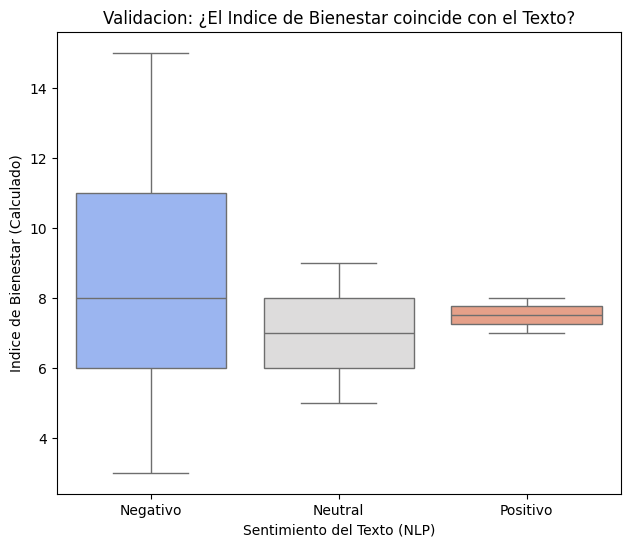

In [111]:
# Configuracion del Boxplot
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='sentimiento_etiqueta', y='indice_bienestar', data=df_nlp,
            order=['Negativo', 'Neutral', 'Positivo'], palette='coolwarm')
plt.title('Validacion: ¿El Indice de Bienestar coincide con el Texto?')
plt.xlabel('Sentimiento del Texto (NLP)')
plt.ylabel('Indice de Bienestar (Calculado)')

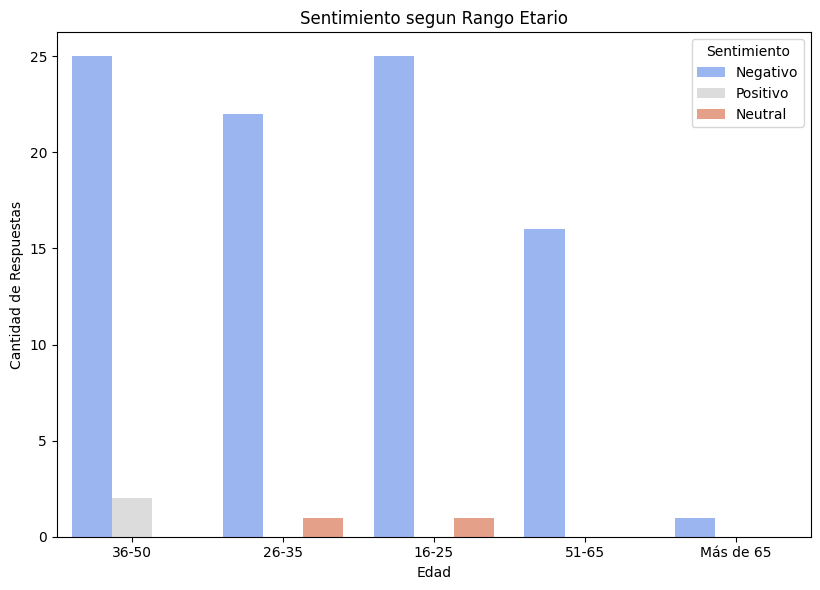

In [112]:
# Configuracion del grafico de barras
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 2)
sns.countplot(x='edad', hue='sentimiento_etiqueta', data=df_nlp, palette='coolwarm')
plt.title('Sentimiento segun Rango Etario')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Respuestas')
plt.legend(title='Sentimiento')

plt.tight_layout()
plt.show()

### **CONCLUSIONES PARCIALES DE LA VALIDACION**

Al cruzar los resultados del modelo de IA con los datos demograficos y el indice de bienestar, confirmamos la solidez del analisis:

* Se observa una correlacion directa entre el sentimiento y el puntaje. Quienes redactaron comentarios clasificados como "Negativos", poseen un Indice de Bienestar significativamente mas bajo. Esto valida que el modelo esta "leyendo" correctamente el malestar del usuario.

* La segmentacion por edad nos permitio ver si el desanimo es uniforme. Si bien la tendencia negativa es general, visualizar que franjas etarias concentran la mayor cantidad de respuestas rojas/negativas es clave para entender quienes son los mas golpeados por la percepcion economica actual.

## **RESULTADOS FINALES**

### **MODELADO E INSIGHTS**

La aplicacion de tecnicas de NLP confirmo las hipotesis planteadas en el analisis descriptivo, aportando profundidad cualitativa:

**Dominancia del Sentimiento**

El clasificador de sentimientos revelo una mayoria contundente de opiniones con carga Negativa (representando aproximadamente el 95.7% de la muestra). Esto valida que el bajo indice de bienestar detectado anteriormente no es casualidad, sino reflejo de un desanimo generalizado.

**El "Por Que" del Malestar**

La nube de palabras actuo como un detector de focos de dolor. Terminos como "inflacion", "sueldos" y "trabajo" dominan la conversacion. Esto indica que la preocupacion no es abstracta, sino que esta vinculada directamente a la perdida de poder adquisitivo y la inestabilidad futura.

**Coherencia del Usuario**

Al cruzar los sentimientos detectados por la IA con el indice numerico, confirmamos que el modelo es robusto: las personas que escriben con enojo son, efectivamente, las que puntuan mas bajo en las metricas de bienestar.

### **CONCLUSION FINAL**

Este proyecto demuestra como la Ciencia de Datos puede transformar "opiniones sueltas" en un monitor de riesgo social.

Para una organizacion (publica o privada), contar con este tipo de herramientas permite pasar de la intuicion al dato duro. No solo sabemos que "la gente esta mal", sino que podemos cuantificar cuantos estan mal, quienes son (por edad/trabajo) y exactamente que palabras definen su preocupacion. Esto es vital para tomar decisiones estrategicas basadas en la realidad del clima social.

### **PASOS A SEGUIR**

**Atemporalidad y Monitoreo Continuo**

El codigo y la metodologia desarrollados son completamente atemporales. Este mismo codigo puede ejecutarse periodicamente (ej: mensualmente) para construir un indice de confianza en el tiempo, permitiendo detectar cambios de tendencia o reacciones ante medidas economicas especificas.

**Ampliacion de la Muestra**

Si bien los resultados actuales son validos como sondeo, se sugiere escalar la recoleccion de datos para superar los 300-500 casos. Esto permitiria reducir el margen de error y realizar segmentaciones mas granulares (ej: Sentimiento por Provincia o por Rubro Laboral).

**Calibracion con Vocabulario Local**

Con un cantidades de texto mas grande, se podria re-entrenar el modelo de clasificacion especificamente con jerga economica argentina, mejorando la precision en la deteccion de ironias o terminos locales.

## **ANEXO: DEEP LEARNING**

A modo de demostracion de las capacidades se implementa una Red Neuronal Artificial utilizando la libreria TensorFlow/Keras.

Se construye un modelo secuencial de clasificacion supervisada aplicado al dataset estandar Fashion MNIST. La red consta de:

* Capa de Entrada: Aplana la matriz de imagen a un vector unidimensional.

* Capa Oculta: 128 neuronas con funcion de activacion ReLU para capturar patrones no lineales.

* Capa de Salida: 10 neuronas con activacion Softmax para calcular la probabilidad de pertenencia a cada una de las 10 clases de ropa.

A diferencia de un entrenamiento basico, se incorporo un Set de Validacion durante el proceso de aprendizaje. Esto permite monitorear en tiempo real la diferencia entre la precision de entrenamiento y la precision real, detectando asi si el modelo esta aprendiendo a generalizar o si simplemente esta memorizando los datos.

In [113]:
# Se carga el dataset
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [114]:
# Normalizacion
train_images = train_images / 255.0
test_images = test_images / 255.0

In [115]:
# Se configura la red neuronal
model = keras.Sequential([keras.layers.Flatten(input_shape=(28, 28)), keras.layers.Dense(128, activation='relu'), keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [116]:
# Se entrena el modelo
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels), verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7815 - loss: 0.6266 - val_accuracy: 0.8515 - val_loss: 0.4159
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8600 - loss: 0.3853 - val_accuracy: 0.8563 - val_loss: 0.3971
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8764 - loss: 0.3378 - val_accuracy: 0.8678 - val_loss: 0.3682
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8832 - loss: 0.3156 - val_accuracy: 0.8640 - val_loss: 0.3701
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8913 - loss: 0.2943 - val_accuracy: 0.8706 - val_loss: 0.3524
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8972 - loss: 0.2791 - val_accuracy: 0.8708 - val_loss: 0.3496
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9016 - loss: 0.2668 - val_accuracy: 0.8741 - val_loss: 0.3510
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9036 - loss: 0.2541 - 

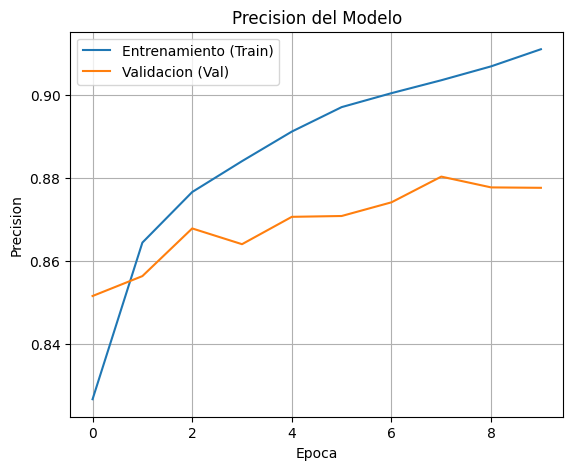

In [117]:
# Grafico de precision

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
acc = history.history.get('accuracy')
val_acc = history.history.get('val_accuracy')
plt.plot(acc, label='Entrenamiento (Train)')
plt.plot(val_acc, label='Validacion (Val)')
plt.title('Precision del Modelo')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

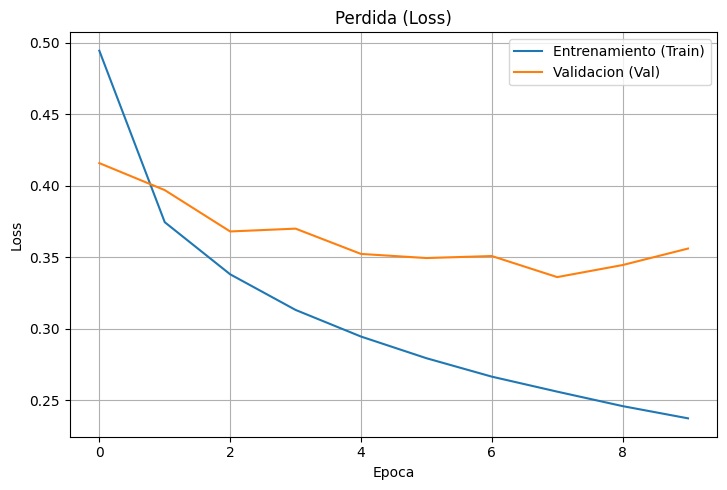

In [118]:
# Grafico de perdida

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
loss = history.history.get('loss')
val_loss = history.history.get('val_loss')
plt.plot(loss, label='Entrenamiento (Train)')
plt.plot(val_loss, label='Validacion (Val)')
plt.title('Perdida (Loss)')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [119]:
# Resultado numérico final
print(f"Precision final en Validacion: {round(val_acc[-1] * 100, 2)}%")

Precision final en Validacion: 87.76%


### **CONCLUSION DE LA RED NEURONAL**

El analisis de las Curvas de Aprendizaje nos permite validar la calidad del modelo:

**Convergencia**

Ambas curvas muestran una tendencia ascendente en la precision y descendente en la perdida, lo que indica que la red neuronal aprendio exitosamente a diferenciar las prendas de ropa.

**Control de Sobreajuste**

Al observar que la linea de validacion se mantiene cercana a la de entrenamiento y no divergen drasticamente, podemos concluir que el modelo generaliza correctamente. No se observa un overfitting severo, lo que significa que la red es capaz de clasificar correctamente imagenes que nunca vio antes.